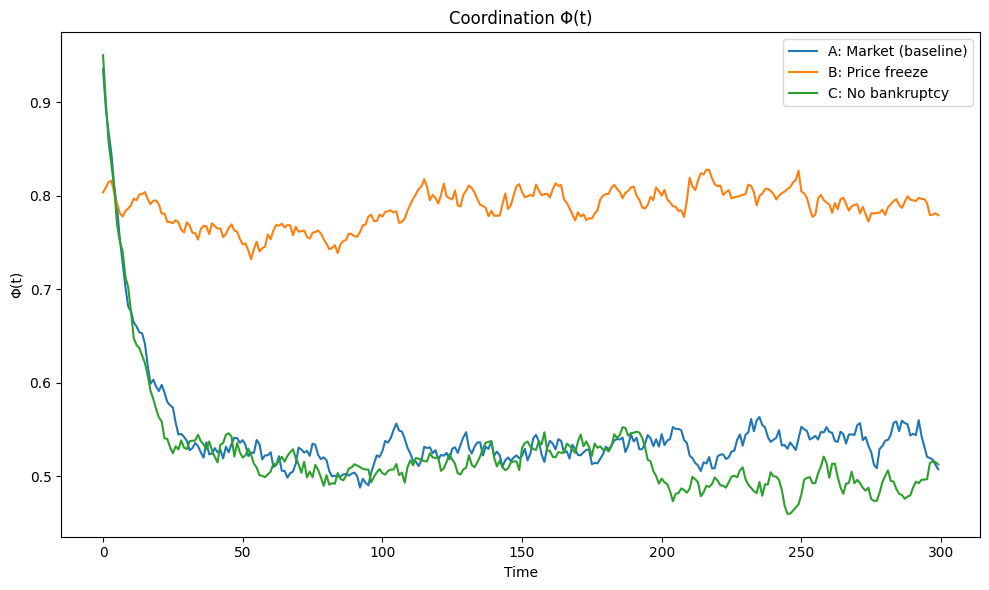

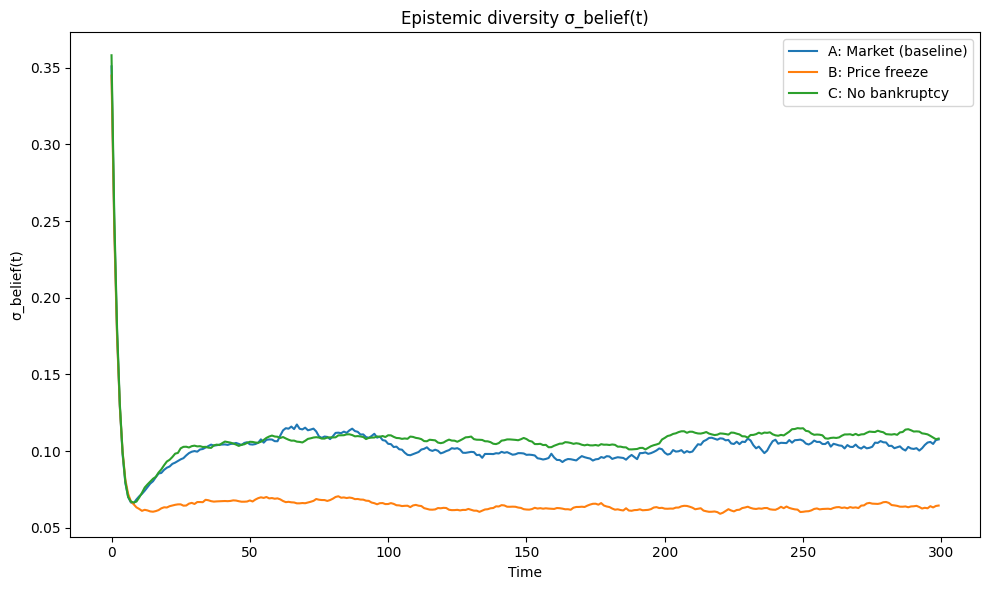

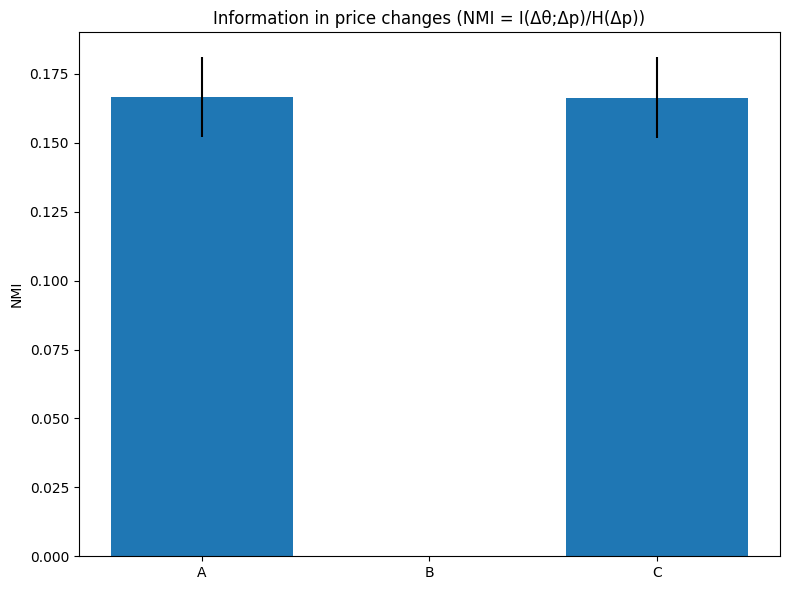

Summary (mean ± sd over runs):


,Experiment,Phi_final_mean,Phi_final_sd,sigma_belief_final_mean,sigma_belief_final_sd,NMI_mean,NMI_sd
0,A: Market (baseline),0.507392,0.118018,0.107632,0.020558,0.166583,0.014415
1,B: Price freeze,0.779230,0.130774,0.064510,0.017069,0.000000,0.000000
2,C: No bankruptcy,0.512577,0.176228,0.108201,0.027953,0.166304,0.014649



Files generated:
- coordination.png
- dispersion.png
- information.png
- results_table.csv


In [ ]:
# ============================================================
# Hayekian Discovery ABM (single-good scalar version)
# Experiments:
#   A: Market (baseline)
#   B: Price freeze (fixed price_freeze)
#   C: No bankruptcy
#
# Outputs:
#   - coordination.png
#   - dispersion.png
#   - information.png
#   - results_table.csv
#
# IMPORTANT: NMI is computed on DIFFERENCES:
#   NMI = I(Δtheta; Δprice) / H(Δprice)
# to avoid "structural level-correlation" artifacts in price-freeze.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Information Theory Utilities
# -----------------------------
def mutual_information_discrete(x, y, bins=20, eps=1e-12):
    """
    Discretize x and y into bins and compute MI in nats:
        I(X;Y) = sum p(x,y) log( p(x,y) / (p(x)p(y)) )
    Robust implementation with explicit loops (avoids brittle broadcasting).
    """
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    if len(x) != len(y):
        raise ValueError("x and y must have the same length")

    # Edge case: if either is (almost) constant, MI ~ 0.
    if np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return 0.0

    # Histogram bin edges
    x_edges = np.histogram_bin_edges(x, bins=bins)
    y_edges = np.histogram_bin_edges(y, bins=bins)

    # 2D histogram
    joint_counts, _, _ = np.histogram2d(x, y, bins=[x_edges, y_edges])
    joint = joint_counts / (np.sum(joint_counts) + eps)

    # Marginals
    px = np.sum(joint, axis=1)  # shape (Bx,)
    py = np.sum(joint, axis=0)  # shape (By,)

    mi = 0.0
    for i in range(joint.shape[0]):
        for j in range(joint.shape[1]):
            pxy = joint[i, j]
            if pxy > 0:
                mi += pxy * (np.log(pxy + eps) - np.log(px[i] + eps) - np.log(py[j] + eps))
    return float(mi)

def entropy_discrete(x, bins=20, eps=1e-12):
    """Entropy in nats using discretization."""
    x = np.asarray(x).ravel()
    if np.std(x) < 1e-12:
        return 0.0
    edges = np.histogram_bin_edges(x, bins=bins)
    counts, _ = np.histogram(x, bins=edges)
    p = counts / (np.sum(counts) + eps)
    h = 0.0
    for pi in p:
        if pi > 0:
            h -= pi * np.log(pi + eps)
    return float(h)

def nmi_discrete(x, y, bins=20, eps=1e-12):
    """
    NMI = MI/H(Y) (in nats/nats), robust to constant Y (returns 0).
    """
    hY = entropy_discrete(y, bins=bins, eps=eps)
    if hY < 1e-12:
        return 0.0
    mi = mutual_information_discrete(x, y, bins=bins, eps=eps)
    return float(mi / (hY + eps))

# -----------------------------
# Core Simulation
# -----------------------------
def simulate_one_run(
    experiment="A",
    N=100,
    T=300,
    seed=0,
    # Theta OU dynamics
    mu_theta=1.0,
    theta0=1.0,
    ou_rho=0.05,         # mean reversion strength
    sigma_theta=0.05,    # OU noise
    # Signals
    sigma_eps=0.2,
    # Learning
    alpha=0.3,
    frac_type_A=0.5,
    ws_A=0.7, ws_B=0.3,
    # Market / price update
    eta=0.1,
    sigma_xi=0.02,
    price0=1.0,
    price_damping=0.02,  # damping towards mu_theta (institutional anchor)
    # Demand / supply (single-good)
    dbar=1.0,
    beta_d=0.5,
    beta_o=0.5,
    c_mean=0.8,
    c_sd=0.05,
    lam_alert=0.6,
    # Capital / selection
    K0=1.0,
    Kmin=0.2,
    fixed_cost=0.001,
    kappa_epistemic=0.10,  # epistemic penalty in profit
    no_bankruptcy=False,
    # Price freeze
    price_freeze=0.8,
    # Numeric stabilizers
    price_clip=(0.01, 10.0),
    dist0_fixed=1.0
):
    rng = np.random.default_rng(seed)

    # Types
    is_type_A = rng.random(N) < frac_type_A
    ws = np.where(is_type_A, ws_A, ws_B)
    wp = 1.0 - ws

    # Costs per agent (for supply)
    c_i = rng.normal(c_mean, c_sd, size=N)

    # Capital
    K = np.full(N, K0, dtype=float)

    # Initial beliefs around mu_theta with dispersion 0.5 as agreed earlier
    beliefs = rng.normal(loc=1.0, scale=0.5, size=N).astype(float)

    # Initial theta and price
    theta = float(theta0)
    price = float(price0)

    # Time series storage
    theta_series = np.zeros(T, dtype=float)
    price_series = np.zeros(T, dtype=float)
    sigma_belief_series = np.zeros(T, dtype=float)
    phi_series = np.zeros(T, dtype=float)

    # Fixed normalization to avoid blowups when initial distance ~0
    dist0 = float(dist0_fixed)

    for t in range(T):
        # --- theta OU update ---
        # theta_{t+1} = theta_t + rho*(mu - theta_t) + N(0, sigma_theta)
        theta = theta + ou_rho * (mu_theta - theta) + rng.normal(0.0, sigma_theta)
        theta_series[t] = theta

        # --- private signals ---
        signals = theta + rng.normal(0.0, sigma_eps, size=N)

        # --- belief update ---
        beliefs = (1.0 - alpha) * beliefs + alpha * (ws * signals + wp * price)

        # --- market step ---
        if experiment == "B":
            # Price freeze: fixed exogenous price (not responding)
            price = float(price_freeze)
        else:
            # Demand and supply (single-good)
            # demand_i = max(0, dbar - beta_d*price + lam*(belief - price))
            demand = np.maximum(
                0.0,
                dbar - beta_d * price + lam_alert * (beliefs - price)
            )
            # supply_i = max(0, beta_o*price - c_i)
            supply = np.maximum(0.0, beta_o * price - c_i)

            # Excess demand (global, for this simplified version)
            ED = np.mean(demand - supply)

            # Price update + noise
            price = price + eta * ED + rng.normal(0.0, sigma_xi)

            # Damping to institutional anchor (mu_theta)
            price = (1.0 - price_damping) * price + price_damping * mu_theta

            # Clip for numerical stability
            lo, hi = price_clip
            price = float(np.clip(price, lo, hi))

        price_series[t] = price

        # --- coordination metric ---
        # Phi = 1 - |p - theta| / dist0
        phi_series[t] = 1.0 - (abs(price - theta) / dist0)

        # --- epistemic diversity ---
        sigma_belief_series[t] = float(np.std(beliefs))

        # --- profits and selection (A and C share profit logic) ---
        if experiment in ["A", "C"]:
            # quantity traded proxy = min(demand_i, supply_i) (only meaningful if market)
            # In this simplified global version, approximate per-agent traded quantity:
            traded = np.minimum(demand, supply)

            # Profit = (price - cost)*q - fixed_cost - kappa*(belief-theta)^2
            profit = (price - c_i) * traded - fixed_cost - kappa_epistemic * (beliefs - theta) ** 2

            # Update capital
            K = K + profit

            # Bankruptcy / replacement
            if (experiment == "A") and (not no_bankruptcy):
                bankrupt = K < Kmin
                if np.any(bankrupt):
                    # replace: reset capital, beliefs, type, cost
                    nb = np.sum(bankrupt)
                    K[bankrupt] = K0
                    beliefs[bankrupt] = rng.normal(loc=1.0, scale=0.5, size=nb)
                    new_is_A = rng.random(nb) < frac_type_A
                    is_type_A[bankrupt] = new_is_A
                    ws[bankrupt] = np.where(new_is_A, ws_A, ws_B)
                    wp[bankrupt] = 1.0 - ws[bankrupt]
                    c_i[bankrupt] = rng.normal(c_mean, c_sd, size=nb)

            # No bankruptcy in C by construction
            if experiment == "C":
                pass

    return theta_series, price_series, sigma_belief_series, phi_series

# -----------------------------
# Run Experiments
# -----------------------------
def run_experiments(
    runs=50,
    N=100,
    T=300,
    bins_mi=20,
    seed_base=12345,
    price_freeze=0.8,
    sigma_xi=0.02,
    kappa_epistemic=0.10
):
    # Store per-experiment aggregates
    exps = ["A", "B", "C"]
    exp_names = {
        "A": "A: Market (baseline)",
        "B": "B: Price freeze",
        "C": "C: No bankruptcy"
    }

    Phi_all = {e: [] for e in exps}
    Sig_all = {e: [] for e in exps}
    NMI_all = {e: [] for e in exps}

    Phi_mean_series = {}
    Sig_mean_series = {}

    for e in exps:
        phi_runs = []
        sig_runs = []

        for r in range(runs):
            seed = seed_base + 1000 * (ord(e) - ord("A")) + r

            theta_s, price_s, sig_s, phi_s = simulate_one_run(
                experiment=e,
                N=N,
                T=T,
                seed=seed,
                price_freeze=price_freeze,
                sigma_xi=sigma_xi,
                kappa_epistemic=kappa_epistemic,
                no_bankruptcy=(e == "C")  # redundant but explicit
            )

            phi_runs.append(phi_s)
            sig_runs.append(sig_s)

            # ---- NMI ON DIFFERENCES (Δtheta, Δprice) ----
            dtheta = np.diff(theta_s)
            dprice = np.diff(price_s)

            nmi_val = nmi_discrete(dtheta, dprice, bins=bins_mi)
            NMI_all[e].append(nmi_val)

            # Final metrics (for table)
            Phi_all[e].append(phi_s[-1])
            Sig_all[e].append(sig_s[-1])

        # Mean time series over runs
        Phi_mean_series[e] = np.mean(np.vstack(phi_runs), axis=0)
        Sig_mean_series[e] = np.mean(np.vstack(sig_runs), axis=0)

    # Summary table
    rows = []
    for e in exps:
        rows.append({
            "Experiment": exp_names[e],
            "Phi_final_mean": float(np.mean(Phi_all[e])),
            "Phi_final_sd": float(np.std(Phi_all[e], ddof=1)),
            "sigma_belief_final_mean": float(np.mean(Sig_all[e])),
            "sigma_belief_final_sd": float(np.std(Sig_all[e], ddof=1)),
            "NMI_mean": float(np.mean(NMI_all[e])),
            "NMI_sd": float(np.std(NMI_all[e], ddof=1)),
        })
    summary = pd.DataFrame(rows)

    # Plots
    tgrid = np.arange(T)

    plt.figure(figsize=(10, 6))
    for e in exps:
        plt.plot(tgrid, Phi_mean_series[e], label=exp_names[e])
    plt.title("Coordination Φ(t)")
    plt.xlabel("Time")
    plt.ylabel("Φ(t)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("coordination.png", dpi=150)
    plt.show()

    plt.figure(figsize=(10, 6))
    for e in exps:
        plt.plot(tgrid, Sig_mean_series[e], label=exp_names[e])
    plt.title("Epistemic diversity σ_belief(t)")
    plt.xlabel("Time")
    plt.ylabel("σ_belief(t)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("dispersion.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 6))
    means = [summary.loc[i, "NMI_mean"] for i in range(len(summary))]
    sds = [summary.loc[i, "NMI_sd"] for i in range(len(summary))]
    plt.bar(["A", "B", "C"], means, yerr=sds)
    plt.title("Information in price changes (NMI = I(Δθ;Δp)/H(Δp))")
    plt.ylabel("NMI")
    plt.tight_layout()
    plt.savefig("information.png", dpi=150)
    plt.show()

    # Save table
    summary.to_csv("results_table.csv", index=False)

    print("Summary (mean ± sd over runs):")
    display(summary)

    print("\nFiles generated:")
    print("- coordination.png")
    print("- dispersion.png")
    print("- information.png")
    print("- results_table.csv")

    return summary

# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    # You can adjust these three knobs (as per consensus) here if needed:
    RUNS = 50
    N = 100
    T = 300
    BINS_MI = 20

    PRICE_FREEZE = 0.8      # last experimental setting agreed
    SIGMA_XI = 0.02         # reduced price noise
    KAPPA_EPISTEMIC = 0.10  # epistemic selection strength

    summary = run_experiments(
        runs=RUNS,
        N=N,
        T=T,
        bins_mi=BINS_MI,
        seed_base=12345,
        price_freeze=PRICE_FREEZE,
        sigma_xi=SIGMA_XI,
        kappa_epistemic=KAPPA_EPISTEMIC
    )